# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Nasyrun Adetiya
- **Email:** nasyrunadetiya1@gmail.com
- **ID Dicoding:** cfcc198d6y1279

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1 Bagaimana tren fluktuasi rata-rata polusi PM2.5 di Beijing selama periode observasi (Tahun 2013 hingga 2017)?
- Pertanyaan 2 Faktor cuaca apa (seperti Suhu, Curah Hujan, atau Tekanan Udara) yang memiliki korelasi paling kuat terhadap peningkatan kualitas udara buruk (PM2.5) di Beijing pada periode 2013-2017?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

## Data Wrangling

### Gathering Data

In [2]:
# Mencari semua file CSV di dalam folder data
path = 'data/'
all_files = glob.glob(os.path.join(path, "*.csv"))

# Menggabungkan semua file CSV menjadi satu DataFrame
df_list = []
for file in all_files:
    df_temp = pd.read_csv(file)
    df_list.append(df_temp)

aq_df = pd.concat(df_list, ignore_index=True)

# Menampilkan 5 baris pertama
aq_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station
0,1,2013,3,1,0,6.0,18.0,5.0,NaN,800.0,88.0,0.1,1021.1,-18.6,0.0,NW,4.4,Gucheng
1,2,2013,3,1,1,6.0,15.0,5.0,NaN,800.0,88.0,-0.3,1021.5,-19.0,0.0,NW,4.0,Gucheng
2,3,2013,3,1,2,5.0,18.0,NaN,NaN,700.0,52.0,-0.7,1021.5,-19.8,0.0,WNW,4.6,Gucheng
3,4,2013,3,1,3,6.0,20.0,6.0,NaN,NaN,NaN,-1.0,1022.7,-21.2,0.0,W,2.8,Gucheng
4,5,2013,3,1,4,5.0,17.0,5.0,NaN,600.0,73.0,-1.3,1023.0,-21.4,0.0,WNW,3.6,Gucheng


**Insight:**
- Kita menggabungkan 12 dataset dari berbagai stasiun pengamatan di Beijing menjadi satu DataFrame utuh agar analisis bisa dilakukan secara komprehensif.

### Assessing Data

In [3]:
# Memeriksa tipe data dan missing values
aq_df.info()

# Memeriksa jumlah missing values
print("\nJumlah Missing Values:")
print(aq_df.isna().sum())

# Memeriksa duplikasi data
print("\nJumlah Duplikasi: ", aq_df.duplicated().sum())

# Ringkasan parameter statistik
aq_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420768 entries, 0 to 420767
Data columns (total 18 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   No       420768 non-null  int64  
 1   year     420768 non-null  int64  
 2   month    420768 non-null  int64  
 3   day      420768 non-null  int64  
 4   hour     420768 non-null  int64  
 5   PM2.5    412029 non-null  float64
 6   PM10     414319 non-null  float64
 7   SO2      411747 non-null  float64
 8   NO2      408652 non-null  float64
 9   CO       400067 non-null  float64
 10  O3       407491 non-null  float64
 11  TEMP     420370 non-null  float64
 12  PRES     420375 non-null  float64
 13  DEWP     420365 non-null  float64
 14  RAIN     420378 non-null  float64
 15  wd       418946 non-null  object 
 16  WSPM     420450 non-null  float64
 17  station  420768 non-null  object 
dtypes: float64(11), int64(5), object(2)
memory usage: 57.8+ MB

Jumlah Missing Values:
No             0
year

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,WSPM
count,420768.000000,420768.000000,420768.000000,420768.000000,420768.000000,412029.000000,414319.000000,411747.000000,408652.000000,400067.000000,407491.000000,420370.000000,420375.000000,420365.000000,420378.000000,420450.000000
mean,17532.500000,2014.662560,6.522930,15.729637,11.500000,79.793428,104.602618,15.830835,50.638586,1230.766454,57.372271,13.538976,1010.746982,2.490822,0.064476,1.729711
std,10122.116943,1.177198,3.448707,8.800102,6.922195,80.822391,91.772426,21.650603,35.127912,1160.182716,56.661607,11.436139,10.474055,13.793847,0.821004,1.246386
min,1.000000,2013.000000,1.000000,1.000000,0.000000,2.000000,2.000000,0.285600,1.026500,100.000000,0.214200,-19.900000,982.400000,-43.400000,0.000000,0.000000
25%,8766.750000,2014.000000,4.000000,8.000000,5.750000,20.000000,36.000000,3.000000,23.000000,500.000000,11.000000,3.100000,1002.300000,-8.900000,0.000000,0.900000
50%,17532.500000,2015.000000,7.000000,16.000000,11.500000,55.000000,82.000000,7.000000,43.000000,900.000000,45.000000,14.500000,1010.400000,3.100000,0.000000,1.400000
75%,26298.250000,2016.000000,10.000000,23.000000,17.250000,111.000000,145.000000,20.000000,71.000000,1500.000000,82.000000,23.300000,1019.000000,15.100000,0.000000,2.200000
max,35064.000000,2017.000000,12.000000,31.000000,23.000000,999.000000,999.000000,500.000000,290.000000,10000.000000,1071.000000,41.600000,1042.800000,29.100000,72.500000,13.200000


**Insight:**
- Terdapat cukup banyak missing values (nilai NaN) pada kolom polutan (PM2.5, PM10, dll) dan beberapa variabel cuaca. Data juga belum memiliki kolom dengan tipe datetime yang menyatukan tahun, bulan, hari, dan jam.


### Cleaning Data

In [ ]:
# 1. Menyatukan kolom year, month, day, hour menjadi tipe datetime
aq_df['datetime'] = pd.to_datetime(aq_df[['year', 'month', 'day', 'hour']])

# 2. Menangani missing values=
# Karena ini data time-series, metode interpolasi atau forward fill (ffill) lebih cocok 
# agar mengikuti tren waktu sebelumnya, namun di sini kita gunakan forward fill
aq_df.ffill(inplace=True)

# Cek kembali apakah masih ada missing values
print(aq_df.isna().sum())

# Menyimpan data yang sudah bersih untuk dashboard
aq_df.to_csv('dashboard/main_data.csv', index=False)

No           0
year         0
month        0
day          0
hour         0
PM2.5        0
PM10         0
SO2          0
NO2         20
CO           0
O3           0
TEMP         0
PRES         0
DEWP         0
RAIN         0
wd           0
WSPM         0
station      0
datetime     0
dtype: int64


**Insight:**
- Kolom waktu telah disatukan ke dalam format datetime untuk mempermudah analisis time-series. Missing values telah diatasi menggunakan metode forward fill yang mempertahankan kontinuitas urutan waktu.


## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
# Melihat rata-rata polusi PM2.5 berdasarkan Stasiun
aq_df.groupby('station')['PM2.5'].mean().sort_values(ascending=False)

# Melihat korelasi antar variabel numerik
numeric_cols = aq_df.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr()

**Insight:**
- Stasiun tertentu memiliki rata-rata PM2.5 yang lebih tinggi dibandingkan yang lain. Nanti kita akan visualisasikan matriks korelasinya.


## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana tren fluktuasi rata-rata polusi PM2.5 di Beijing selama periode observasi (Tahun 2013 hingga 2017)?

/var/folders/d4/vr68frq17qd4kcrjnm4s5jcr0000gp/T/ipykernel_44575/1350334017.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_pm25 = aq_df.resample('M', on='datetime')['PM2.5'].mean().reset_index()


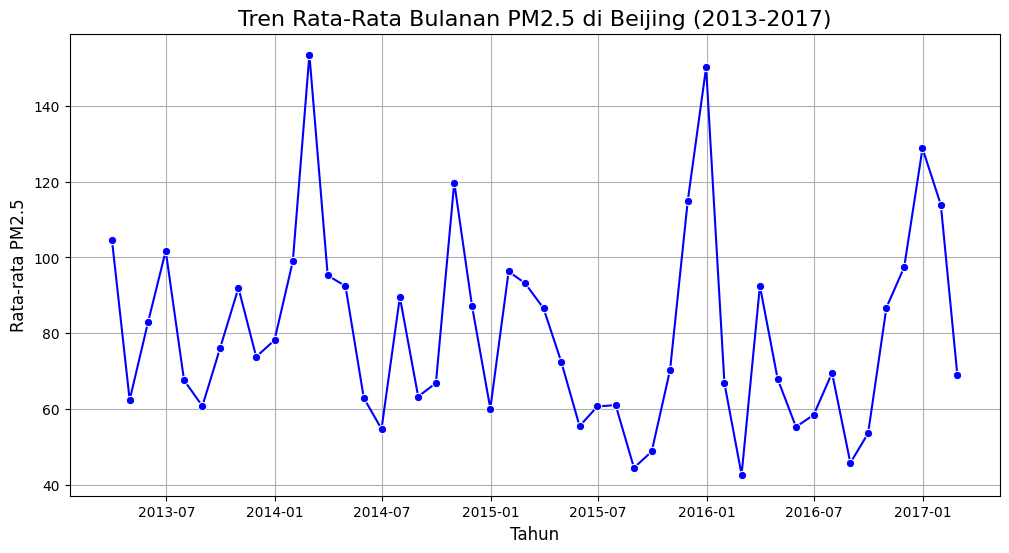

In [6]:
plt.figure(figsize=(12, 6))
# Resample data per bulan agar grafik tidak terlalu padat
monthly_pm25 = aq_df.resample('M', on='datetime')['PM2.5'].mean().reset_index()

sns.lineplot(data=monthly_pm25, x='datetime', y='PM2.5', marker='o', color='b')
plt.title('Tren Rata-Rata Bulanan PM2.5 di Beijing (2013-2017)', fontsize=16)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Rata-rata PM2.5', fontsize=12)
plt.grid(True)
plt.show()

**Insight:**
- Polusi PM2.5 cenderung memiliki pola musiman (meningkat tajam di akhir/awal tahun yang identik dengan musim dingin, dan menurun di pertengahan tahun).

### Pertanyaan 2: Faktor cuaca apa (seperti Suhu, Curah Hujan, atau Tekanan Udara) yang memiliki korelasi paling kuat terhadap peningkatan kualitas udara buruk (PM2.5) di Beijing pada periode 2013-2017?

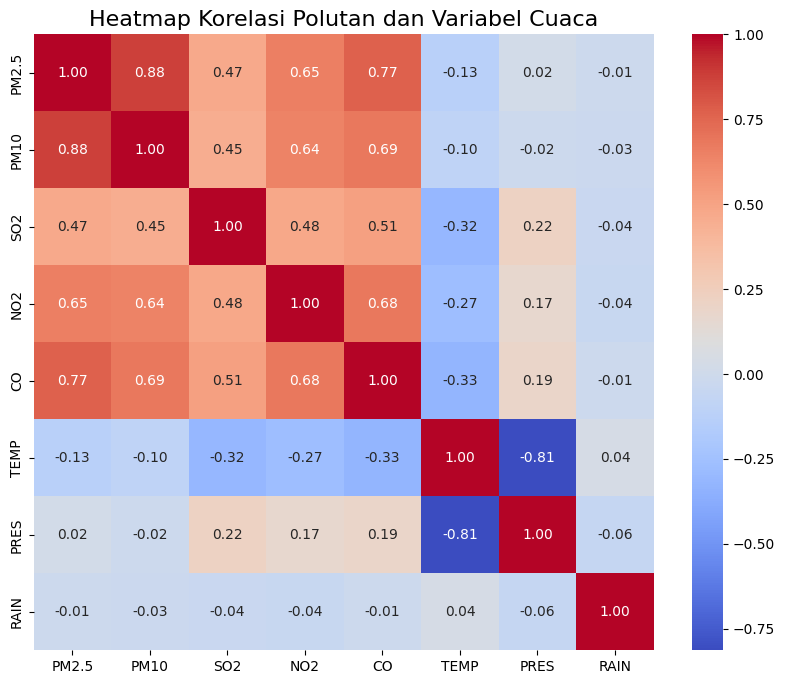

In [7]:
plt.figure(figsize=(10, 8))
# Kita pilih beberapa kolom yang relevan untuk heatmap
cols_to_plot = ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'TEMP', 'PRES', 'RAIN']
sns.heatmap(aq_df[cols_to_plot].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap Korelasi Polutan dan Variabel Cuaca', fontsize=16)
plt.show()

**Insight:**
- Ada korelasi negatif antara PM2.5 dengan Suhu (TEMP), artinya ketika suhu turun, polusi cenderung naik. Curah hujan (RAIN) tidak menunjukkan korelasi linear yang kuat terhadap PM2.5 secara harian.


## Analisis Lanjutan (Opsional)

/var/folders/d4/vr68frq17qd4kcrjnm4s5jcr0000gp/T/ipykernel_44575/1595927085.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=aq_df, x='AQI_Category', order=['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous'], palette='viridis')


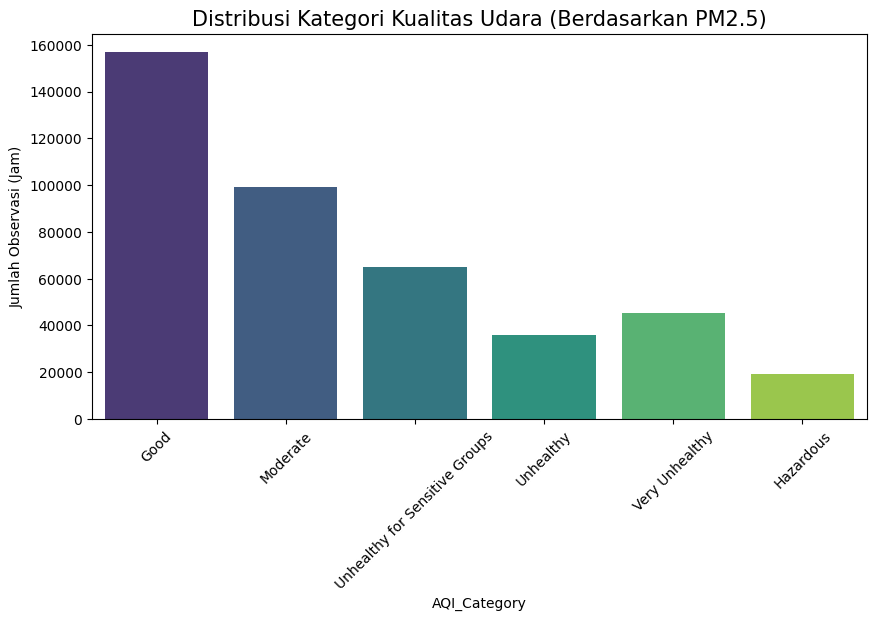

In [8]:
# Tujuan: Mengelompokkan (Binning) kualitas udara berdasarkan standar PM2.5 menjadi beberapa kategori
def categorize_aqi(pm25):
    if pm25 <= 35:
        return 'Good'
    elif pm25 <= 75:
        return 'Moderate'
    elif pm25 <= 115:
        return 'Unhealthy for Sensitive Groups'
    elif pm25 <= 150:
        return 'Unhealthy'
    elif pm25 <= 250:
        return 'Very Unhealthy'
    else:
        return 'Hazardous'

aq_df['AQI_Category'] = aq_df['PM2.5'].apply(categorize_aqi)

# Visualisasi distribusi kategori
plt.figure(figsize=(10, 5))
sns.countplot(data=aq_df, x='AQI_Category', order=['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous'], palette='viridis')
plt.title('Distribusi Kategori Kualitas Udara (Berdasarkan PM2.5)', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Jumlah Observasi (Jam)')
plt.show()

## Conclusion

- Tren polusi PM2.5 di Beijing memiliki fluktuasi musiman yang sangat jelas. Polusi mencapai puncaknya pada bulan-bulan musim dingin (akhir dan awal tahun), dan berada di tingkat terendah saat pertengahan tahun (musim panas).
- Suhu (TEMP) memiliki korelasi negatif dengan PM2.5, memvalidasi temuan pertama bahwa udara dingin seringkali bertepatan dengan tingkat polusi yang tinggi. Sementara itu, faktor cuaca lain seperti hujan (RAIN) tidak menunjukkan pengaruh korelasi linear yang kuat dalam menekan PM2.5 berdasarkan matriks ini.